In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df['Month'] = df['Date'].dt.month_name()

In [9]:
df['Year'] = df['Date'].dt.year

In [10]:
bins = [0,18,25,35,50,100]

labels = ['Teen','Young Adult','Adult','Middle Age','Senior']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [11]:
total_sales = df['Total Amount'].sum()

print(total_sales)

456000


In [12]:
category_sales = df.groupby(
    'Product Category'
)['Total Amount'].sum()

print(category_sales)

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


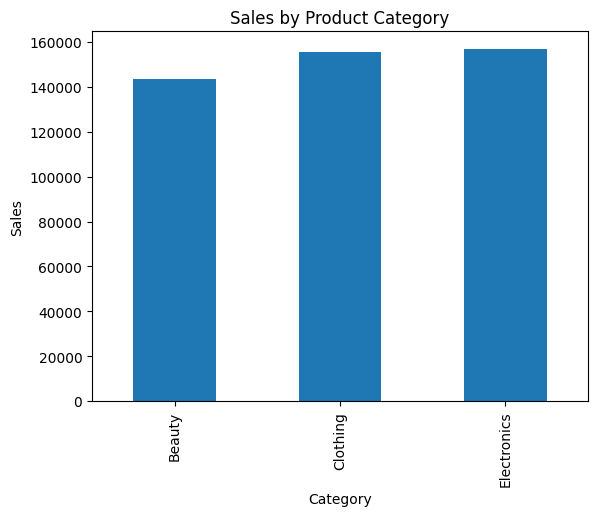

In [13]:
category_sales.plot(kind='bar')

plt.title("Sales by Product Category")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.show()

In [14]:
monthly_sales = df.groupby(
    'Month'
)['Total Amount'].sum()

monthly_sales

Month
April        33870
August       36960
December     44690
February     44060
January      36980
July         35465
June         36715
March        28990
May          53150
November     34920
October      46580
September    23620
Name: Total Amount, dtype: int64

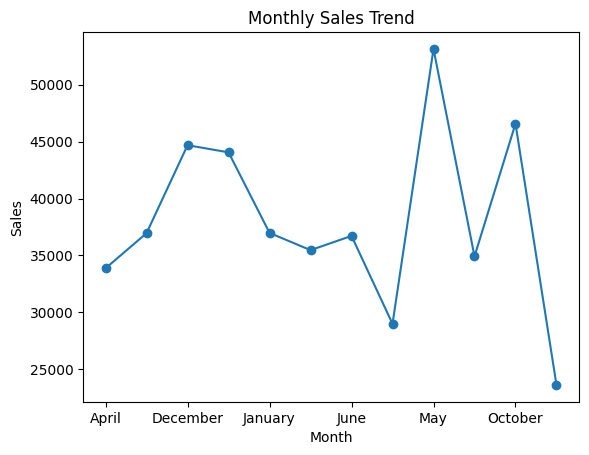

In [15]:
monthly_sales.plot(
    kind='line',
    marker='o'
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

In [16]:
gender_sales = df.groupby(
    'Gender'
)['Total Amount'].sum()

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

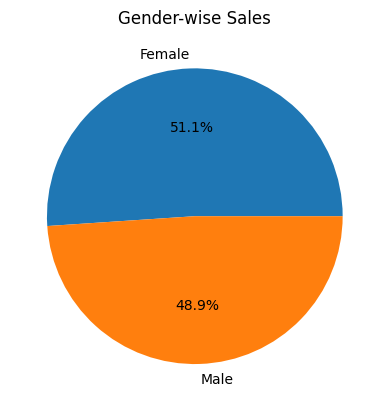

In [17]:
gender_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Gender-wise Sales")

plt.ylabel("")

plt.show()

In [18]:
top_customers = df.groupby(
    'Customer ID'
)['Total Amount'].sum()

top_customers = top_customers.sort_values(
    ascending=False
).head(10)

top_customers

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64

In [19]:
customer_df = df.groupby(
    'Customer ID'
).agg({
    'Total Amount':'sum',
    'Quantity':'sum',
    'Age':'mean'
}).reset_index()

customer_df.head()

,Customer ID,Total Amount,Quantity,Age
0,CUST001,150,3,34.0
1,CUST002,1000,2,26.0
2,CUST003,30,1,50.0
3,CUST004,500,1,37.0
4,CUST005,100,2,30.0


In [20]:
X = customer_df[
    ['Total Amount','Quantity']
]

In [21]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

customer_df['Cluster'] = kmeans.fit_predict(X)

In [22]:
customer_df.head()

,Customer ID,Total Amount,Quantity,Age,Cluster
0,CUST001,150,3,34.0,0
1,CUST002,1000,2,26.0,1
2,CUST003,30,1,50.0,0
3,CUST004,500,1,37.0,0
4,CUST005,100,2,30.0,0


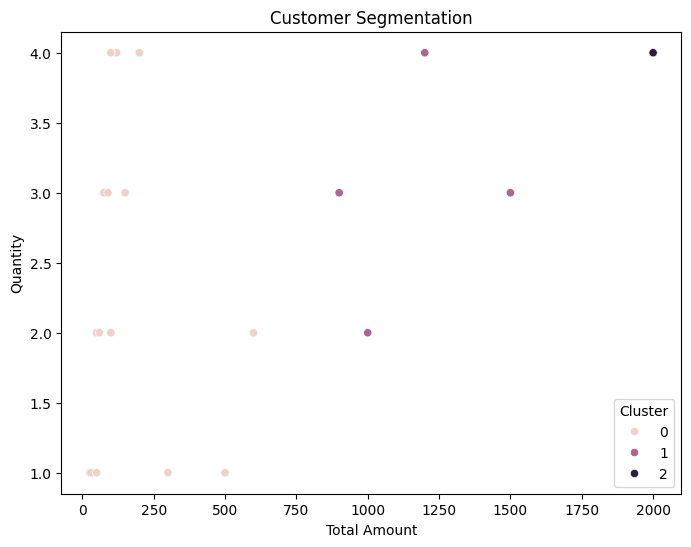

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer_df,
    x='Total Amount',
    y='Quantity',
    hue='Cluster'
)

plt.title("Customer Segmentation")

plt.show()

In [24]:
df.to_csv(
    '../data/cleaned_retail_data.csv',
    index=False
)

In [25]:
customer_df.to_csv(
    '../data/customer_segments.csv',
    index=False
)

In [2]:
df = pd.read_csv('../data/retail_sales_dataset.csv')

df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
